# This noteboook illustrates the solution of the model

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from Chorms import *

do_compile = True # should the c-functions be re-compiled?

import os
os.environ.pop('NoDefaultCurrentDirectoryInExePath', None)

do_reinstall_nlopt = False # If problems with NLOPT during re-compilation of c++ files, then try re-installing NLOPT by swithcing this to True and delete the folder "nlopt-2.4.2-dll64" in the cppfuncs folder before running this notebook.
if do_reinstall_nlopt:
    from EconModel import cpptools
    cpptools.setup_nlopt(folder='cppfuncs/', do_print=False,download=False,unzip=True)

# Setup Model

In [2]:
model = ChormsClass() 
model.link_to_cpp(force_compile=do_compile)

In [3]:
# load/simulate data
model.load_data(do_simulate=True)

In [4]:
# try coarse grid search
model.par.do_gridsearch = True
%time model.solve()

CPU times: total: 27.2 s
Wall time: 3.41 s


In [5]:
model_num = ChormsClass(par={'do_gridsearch':False,'reuse_init':False})
model_num.link_to_cpp(force_compile=False)
model_num.load_data(do_simulate=True)

In [6]:
%time model_num.solve()

CPU times: total: 484 ms
Wall time: 57.6 ms


In [7]:
model_reuse = ChormsClass(par={'do_gridsearch':False,'reuse_init':True})
model_reuse.link_to_cpp(force_compile=False)
model_reuse.load_data(do_simulate=True)

%time model_reuse.solve()

CPU times: total: 156 ms
Wall time: 21 ms


In [8]:
print(model_num.sol.home_w[0:10])
model_num.sol.home_share_exp_w

[0.61302804 1.46343501 1.22575845 0.48634635 0.48636477 1.20263474
 1.0120216  2.08272011 0.79808559 1.84309476]


array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [9]:
%time model_num.solve(do_exp=True)
print(model_num.sol.home_w[0:10])
model_num.sol.home_share_exp_w

CPU times: total: 984 ms
Wall time: 144 ms
[0.61302804 1.46343501 1.22575845 0.48634635 0.48636477 1.20263474
 1.0120216  2.08272011 0.79808559 1.84309476]


array([0.19060831, 0.79765601, 0.59857751, 0.16777245, 0.16777602,
       0.50299252, 0.57712077, 0.83917937, 0.39415037, 0.86218052,
       0.64919422, 0.20388198, 0.56685271, 0.71602592, 0.82660447,
       0.35317397, 0.82891703, 0.18326015, 0.87096552, 0.88282231,
       0.2655187 , 0.86649226, 0.6086052 , 0.46092396, 0.1464514 ,
       0.26130844, 0.16793799, 0.17442596, 0.16647614, 0.18145147,
       0.86291248, 0.75224754, 0.8351583 , 0.24253131, 0.13968844,
       0.86437817, 0.38238367, 0.86860981, 0.17160149, 0.8232421 ,
       0.17523187, 0.18943138, 0.45586811, 0.86204572, 0.84587668,
       0.64247669, 0.50885977, 0.78744545, 0.69888971, 0.26158639,
       0.31789358, 0.85500116, 0.49667939, 0.69226388, 0.413575  ,
       0.66187128, 0.15628635, 0.51002641, 0.47940357, 0.40409855,
       0.55619384, 0.71385133, 0.66725949, 0.15962318, 0.77654245,
       0.22528384, 0.55375245, 0.16703415, 0.60599019, 0.17395962,
       0.79654334, 0.17754551, 0.19536863, 0.88191266, 0.62532

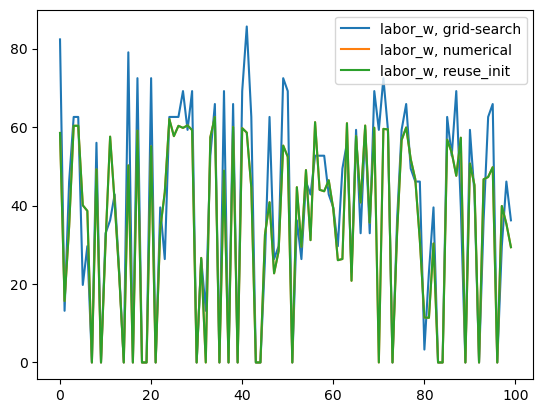

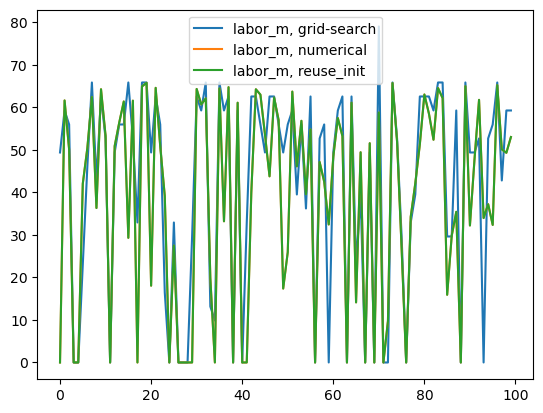

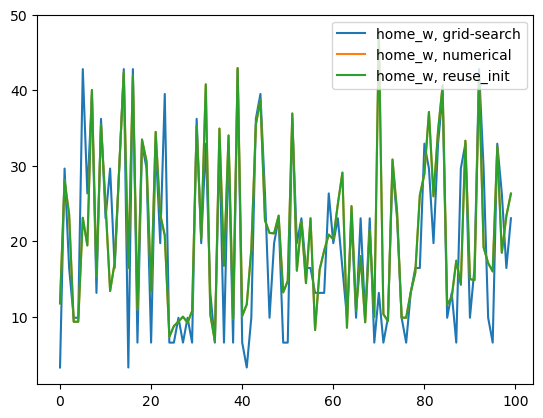

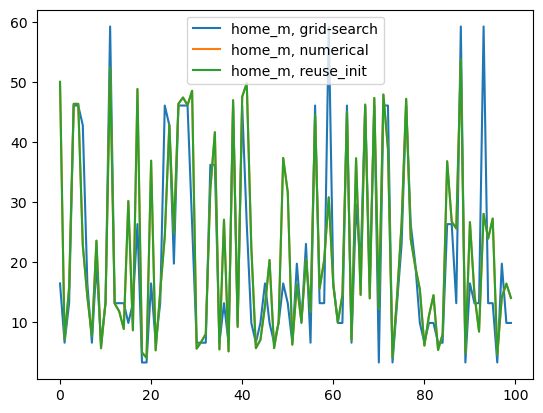

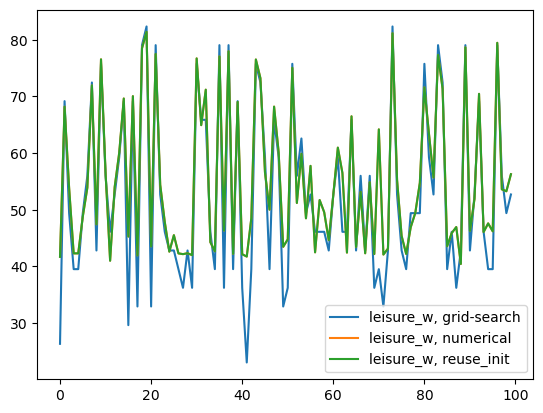

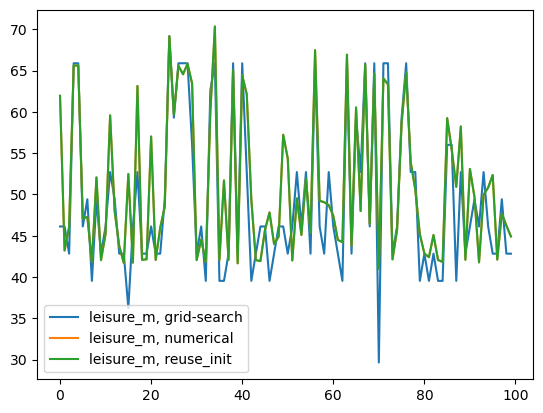

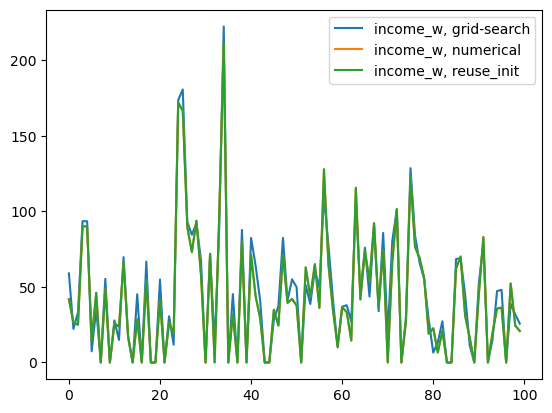

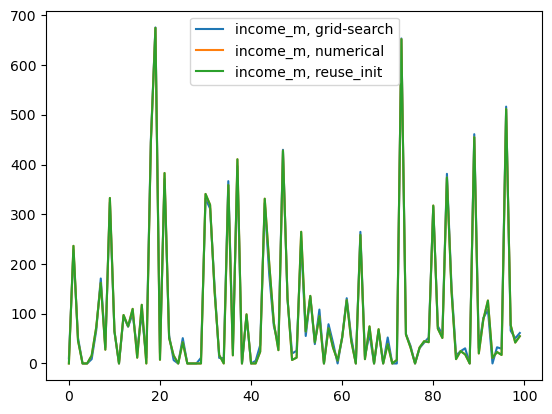

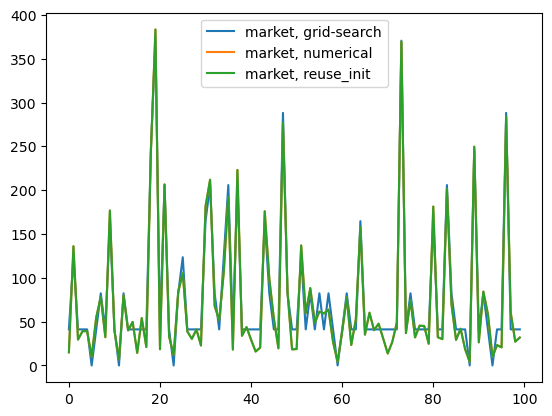

In [10]:
y2w = 1000 / 52 # year to week conversion factor
u2d = 7 # usd to dkk

# compare solution approaches
linestyle='solid'
fig,ax = plt.subplots()
ax.plot(model.sol.labor_w * y2w, label='labor_w, grid-search')
ax.plot(model_num.sol.labor_w * y2w, label='labor_w, numerical')
ax.plot(model_reuse.sol.labor_w * y2w, label='labor_w, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot(model.sol.labor_m * y2w, label='labor_m, grid-search')
ax.plot(model_num.sol.labor_m * y2w, label='labor_m, numerical')
ax.plot(model_reuse.sol.labor_m * y2w, label='labor_m, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot(model.sol.home_w * y2w, label='home_w, grid-search')
ax.plot(model_num.sol.home_w * y2w, label='home_w, numerical')
ax.plot(model_reuse.sol.home_w * y2w, label='home_w, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot(model.sol.home_m * y2w, label='home_m, grid-search')
ax.plot(model_num.sol.home_m * y2w, label='home_m, numerical')
ax.plot(model_reuse.sol.home_m * y2w, label='home_m, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot((model.par.total_time - model.sol.labor_w - model.sol.home_w) * y2w, label='leisure_w, grid-search')
ax.plot((model_num.par.total_time - model_num.sol.labor_w - model_num.sol.home_w) * y2w, label='leisure_w, numerical')
ax.plot((model_reuse.par.total_time - model_reuse.sol.labor_w - model_reuse.sol.home_w) * y2w, label='leisure_w, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot((model.par.total_time - model.sol.labor_m - model.sol.home_m) * y2w, label='leisure_m, grid-search')
ax.plot((model_num.par.total_time - model_num.sol.labor_m - model_num.sol.home_m) * y2w, label='leisure_m, numerical')
ax.plot((model_reuse.par.total_time - model_reuse.sol.labor_m - model_reuse.sol.home_m) * y2w, label='leisure_m, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot(model.sol.labor_w * model.sim.wage_w * u2d, label='income_w, grid-search')
ax.plot(model_num.sol.labor_w * model_num.sim.wage_w * u2d, label='income_w, numerical')
ax.plot(model_reuse.sol.labor_w * model_reuse.sim.wage_w * u2d, label='income_w, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot(model.sol.labor_m * model.sim.wage_m * u2d, label='income_m, grid-search')
ax.plot(model_num.sol.labor_m * model_num.sim.wage_m * u2d, label='income_m, numerical')
ax.plot(model_reuse.sol.labor_m * model_reuse.sim.wage_m * u2d, label='income_m, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot(model.sol.market * u2d, label='market, grid-search')
ax.plot(model_num.sol.market * u2d, label='market, numerical')
ax.plot(model_reuse.sol.market * u2d, label='market, reuse_init',linestyle=linestyle)
ax.legend();

## Test estimator

In [11]:
# test
theta_names = ['util_public','util_leisure_w']
init = np.array([model.par.util_public*0.9,model.par.util_leisure_w*0.9])

%time obj(theta=init,theta_names=theta_names,model=model_num,do_gridsearch=False,do_print=True);

util_public=1.350 util_leisure_w=3.600 ->obj: 0.3416
CPU times: total: 1.02 s
Wall time: 135 ms


In [12]:
se = standard_errors(init,theta_names,model,data_outcomes=None,weight=None,var_list=None,do_gridsearch=False)
print(se)
# [1.03621582e-05 1.68846750e-05]

[0.00019894 0.00012496]


In [13]:
from scipy.optimize import minimize
# theta_names = ['util_public',]
# init = np.array([model.par.util_public])


model = ChormsClass(par={'do_gridsearch':False,'reuse_init':True})
model.link_to_cpp(force_compile=False)
model.load_data(do_simulate=True)


theta_names = ['util_public','util_leisure_w']
init = np.array([model.par.util_public*0.9,model.par.util_leisure_w*0.9])

do_gridsearch = False
data_outcomes = np.column_stack([getattr(model.sim,var) for var in ['labor_w','labor_m','home_w','home_m','market','home_share_exp_w']])

obj_func = lambda theta: obj(theta,theta_names,model,data_outcomes=data_outcomes,weight=None,var_list=None,do_gridsearch=False,do_print=True)

res = minimize(obj_func,init,method='Nelder-Mead',options={'maxiter':1000})



util_public=1.350 util_leisure_w=3.600 ->obj: 0.3417
util_public=1.418 util_leisure_w=3.600 ->obj: 0.1367
util_public=1.350 util_leisure_w=3.780 ->obj: 0.3606
util_public=1.417 util_leisure_w=3.420 ->obj: 0.1546
util_public=1.485 util_leisure_w=3.420 ->obj: 0.1253
util_public=1.552 util_leisure_w=3.330 ->obj: 0.2634
util_public=1.485 util_leisure_w=3.600 ->obj: 0.0853
util_public=1.519 util_leisure_w=3.690 ->obj: 0.0917
util_public=1.552 util_leisure_w=3.420 ->obj: 0.2282
util_public=1.451 util_leisure_w=3.555 ->obj: 0.1013
util_public=1.451 util_leisure_w=3.735 ->obj: 0.0818
util_public=1.434 util_leisure_w=3.892 ->obj: 0.1071
util_public=1.485 util_leisure_w=3.780 ->obj: 0.0631
util_public=1.502 util_leisure_w=3.892 ->obj: 0.0592
util_public=1.468 util_leisure_w=4.027 ->obj: 0.0706
util_public=1.519 util_leisure_w=4.185 ->obj: 0.0648
util_public=1.553 util_leisure_w=4.050 ->obj: 0.0951
util_public=1.489 util_leisure_w=4.033 ->obj: 0.0582
util_public=1.472 util_leisure_w=3.741 ->obj: 

In [14]:
# test log-lik
# model.par.util_public = 0.9
loglik_vec = np.nan + np.ones(model.par.num_N)
model.cpp.LogLik(loglik_vec,model.sol,model.sim,model.par)

loglik_vec[0:20]

# array([-5.51363127, -5.5136312 , -5.5136312 , -5.5136312 , -5.5136312 ,
#        -5.5136312 , -5.51363126, -5.5136312 , -5.51363121, -5.51363121])

array([ 3.63675449,  0.77312235,  3.1491624 , -3.16087183,  3.08906304,
       -0.67595922,  1.63359161, -0.49064234,  4.15844585,  0.29827125,
        1.61340964,  3.96987357,  1.93563485, -0.76425655,  3.08146218,
        2.17569979, -1.56189274,  3.67044095,  0.34818091, -4.14160347])

In [15]:
model.par.wage_cov

np.float64(0.12414632594785238)

In [16]:
%time obj_loglik(init,theta_names,model,do_print=True)

util_public=1.350 util_leisure_w=3.600 ->obj: 12.9181
CPU times: total: 438 ms
Wall time: 63.9 ms


np.float64(12.91813644569443)

In [17]:
loglik_vec = np.nan + np.ones(model.par.num_N)
model.cpp.LogLik(loglik_vec, model.sol, model.sim, model.par)

In [18]:
loglik_vec

array([ 2.09649068e+00, -1.13197241e+01,  3.83562813e+00, -7.28799244e+00,
        2.21719791e+00,  2.72299326e-01,  1.57786613e+00, -1.98505134e+01,
        1.82384245e+00, -5.21698335e+01, -2.67808386e-01,  3.33950499e+00,
       -2.48956572e+00, -6.74743532e+00, -1.13651900e+00, -8.84571473e-02,
       -1.10910207e+01,  1.59883899e+00, -7.55570966e+01, -1.67265549e+02,
        1.45344589e+00, -5.85856584e+01, -1.85244156e+00,  9.78482366e-01,
        2.49682687e+00, -9.58369773e+00,  2.80734500e+00,  6.16178441e+00,
       -3.65604655e+00,  3.15421379e+00, -5.85883708e+01, -3.96148817e+01,
       -1.73197380e+00, -9.29555837e-01,  1.65002577e-01, -4.79073616e+01,
        1.50638032e+00, -7.42616602e+01,  2.02876803e+00,  6.44968562e-01,
        2.07533136e+00, -1.52070311e+00,  5.29405539e+00, -4.71546672e+01,
       -1.19063533e+01, -3.84688849e+00,  3.95445217e+00, -5.98563749e+01,
       -9.43514394e+00,  7.84564900e-01,  1.30669222e+00, -3.22416356e+01,
        2.48763206e-01, -